
## Machine Learning Model Development


## Supervised Learning  => Curso databricks

### 1.1a training Regression Models


# 1.1a - Training Regression Models

## Training Regression and Classification Models

In this demo, we will guide you through essential concepts and practical applications of machine learning. The first demo will be related to fitting a regression model and the second demo will be related classification models. In these demos, you will learn how to retrieve data and fit models using notebooks. In addition, you will learn how to interpret results using visualization tools and various model metrics.

### Learning Objectives:

By the end of this demo, you will be able to;

* Fit a linear regression model on modeling data using the sklearn API.
* Interpret a fit sklearn linear model's coefficients and intercept.
* Fit a decision tree model using sklearn API and training data.
* Visualize a sklearn tree's split points.
* Identify which metrics are tracked by MLflow.

### Requirements

## Classroom Setup

Before starting the demo, run the provided classroom setup script. This script will define configuration variables necessary for the demo. Execute the following cell:

### Other Conventions

Throughout this demo, we will refer to the object `DA`. This object, provided by Databricks Academy, contains variables such as your username, catalog name, schema name, working directory, and dataset locations. Run the code block below to view these details:

---

## Prepare Dataset

In this section, we are going to prepare the dataset for our machine learning models. The dataset we'll be working with is the **California housing dataset**.

The dataset has been loaded, cleaned and saved to a **feature table**. We will read data directly from this table.

Then, we will split the dataset to **train and test** sets.

---

## Load Dataset

This dataset contains information about housing districts in California and **aims to predict the median house value** for California districts, based on various features.

While data cleaning and feature engineering is out of the scope of this demo, we will only map the `ocean_proximity` field.

In [1]:
import pandas as pd

# URL do arquivo bruto (raw) do GitHub
url = "https://raw.githubusercontent.com/sonarsushant/California-House-Price-Prediction/master/housing.csv"

# Carregando os dados
df = pd.read_csv(url)

# Visualizando as primeiras linhas do dataset da Califórnia
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
feature_data_pd = df.copy()

# Conforme a imagem: remover colunas de identificadores únicos se existirem
if 'unique_id' in feature_data_pd.columns:
    feature_data_pd = feature_data_pd.drop(columns=['unique_id'])

# =====================================================================
# MAP OCEAN PROXIMITY (Mapear a proximidade do oceano)
# =====================================================================

# Dicionário de mapeamento
ocean_proximity_mapping = {
    'NEAR BAY': 1,
    '<1H OCEAN': 2,
    'INLAND': 3,
    'NEAR OCEAN': 4,
    'ISLAND': 5
}

# Aplicar o mapeamento na coluna 'ocean_proximity'
#feature_data_pd['ocean_proximity'] = feature_data_pd['ocean_proximity'].map(ocean_proximity_mapping)
feature_data_pd['ocean_proximity'] = feature_data_pd['ocean_proximity'].replace(ocean_proximity_mapping).astype(float)

# Tratar possíveis valores nulos que possam ter surgido ou que já existiam (ex: total_bedrooms)
#feature_data_pd = feature_data_pd.dropna()
feature_data_pd = feature_data_pd.fillna(0)

print("\nExemplo dos dados carregados e mapeados:")
print(feature_data_pd.head())


Exemplo dos dados carregados e mapeados:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  ocean_proximity  
0       322.0       126.0         8.3252            452600.0              1.0  
1      2401.0      1138.0         8.3014            358500.0              1.0  
2       496.0       177.0         7.2574            352100.0              1.0  
3       558.0       219.0         5.6431            341300.0              1.0  
4       565.0       259.0         3.8462            342200.0              1.0  


/tmp/ipykernel_934/2873411638.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  feature_data_pd['ocean_proximity'] = feature_data_pd['ocean_proximity'].replace(ocean_proximity_mapping).astype(float)


## Train / Test Split

Split the dataset into training and testing sets. This is essential for evaluating the performance of machine learning models.

---

## Examine for Potential Co-linearity

Now, let's examine the correlations between predictors to identify potential co-linearity. Understanding the relationships between different features can provide insights into the dataset and help us make informed decisions during the modeling process.

Let's review the **correlation matrix**...

In [3]:
from sklearn.model_selection import train_test_split

# Mostrar a quantidade total de registros antes da divisão
print(f"We have {feature_data_pd.shape[0]} records in our source dataset")

# Split target variable into it's own dataset (Separar a variável alvo)
target_col = "median_house_value"
X_all = feature_data_pd.drop(labels=target_col, axis=1)
y_all = feature_data_pd[target_col]

# Test / train split (Divisão em 80% treino e 20% teste)
# O parâmetro train_size=0.8 equivale ao test_size=0.2 utilizado no passo anterior
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    train_size=0.8,
    random_state=42
)

# Exibir os resultados da divisão exatamente como no output do Databricks
print(f"We have {X_train.shape[0]} records in our training dataset")
print(f"We have {X_test.shape[0]} records in our test dataset")


We have 20640 records in our source dataset
We have 16512 records in our training dataset
We have 4128 records in our test dataset


## Examine for Potential Co-linearity

Now, let's examine the correlations between predictors to identify potential co-linearity. Understanding the relationships between different features can provide insights into the dataset and help us make informed decisions during the modeling process.

Let's review the **correlation matrix in tabular format**. Also, we can create a **graph based on the correlation matrix** to easily inspect the matrix.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Combine X and y into a single DataFrame for simplicity
# (Combina as features de treino e o target para calcular a correlação global)
data = pd.concat([X_train, y_train], axis=1)

# Calculate correlation matrix (Calcular a matriz de correlação)
corr = data.corr()

# Display correlation matrix (Configurar e exibir a matriz em formato tabular)
pd.set_option('display.max_columns', 10)
print(corr)

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924485           -0.101818     0.038676   
latitude            -0.924485  1.000000            0.005296    -0.029224   
housing_median_age  -0.101818  0.005296            1.000000    -0.360922   
total_rooms          0.038676 -0.029224           -0.360922     1.000000   
total_bedrooms       0.063064 -0.059998           -0.320624     0.930489   
population           0.094276 -0.102499           -0.292283     0.857936   
households           0.049306 -0.064061           -0.302796     0.920482   
median_income       -0.017040 -0.076571           -0.121711     0.198268   
ocean_proximity      0.186208 -0.070966           -0.203832     0.012048   
median_house_value  -0.046349 -0.142983            0.103706     0.133989   

                    total_bedrooms  population  households  median_income  \
longitude                 0.063064    0.094276    0.049306      -0.017040   
latitude 

### Display correlation matrix visually

To make it easier to interpret the linear relationships and spot potential co-linearity, we can plot a **Correlogram**.

In this graph:
* The **size** of the circle corresponds to the strength (absolute value) of the correlation.
* The **color** indicates whether the correlation is positive (blue) or negative (red).
* The diagonal is left empty since a feature always has a perfect correlation (1.0) with itself.

/tmp/ipykernel_934/2357054652.py:15: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.gca().add_patch(plt.Circle(


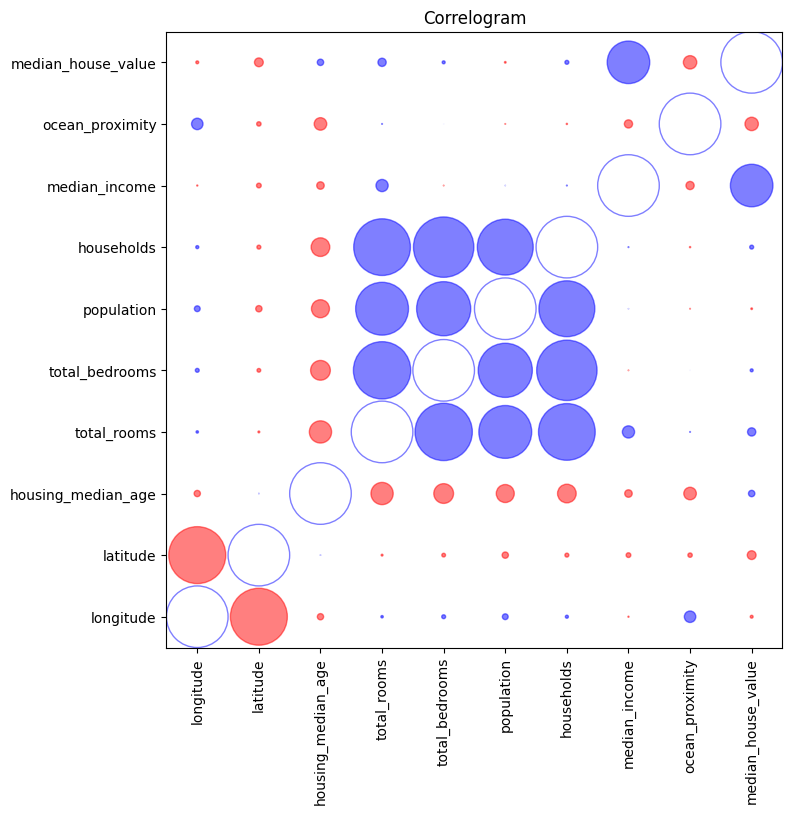

In [5]:
# display correlation matrix visually

# Initialize figure
plt.figure(figsize=(8, 8))

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        # Determine the color based on positive or negative correlation
        color = 'blue' if corr.iloc[i, j] > 0 else 'red'

        # don't fill in circles on the diagonal
        fill = not(i == j)

        # Plot the circle with size corresponding to the absolute value of correlation
        plt.gca().add_patch(plt.Circle(
            (j, i),
            radius=0.5 * np.abs(corr.iloc[i, j]),
            color=color,
            edgecolor=color,
            fill=fill,
            alpha=0.5
        ))

# Adjust plot limits and ticks
plt.xlim(-0.5, len(corr.columns) - 0.5)
plt.ylim(-0.5, len(corr.columns) - 0.5)
plt.gca().set_aspect('equal', adjustable='box')

plt.xticks(np.arange(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(np.arange(len(corr.columns)), corr.columns)

plt.title('Correlogram')
plt.show()

## Fit a Regression Model

To enhance the performance of our regression model, we'll scale our input variables so that they are on a common (standardized) scale. **Standardization ensures that each feature has a mean of 0 and a standard deviation of 1**, which can be beneficial for certain algorithms, including linear regression.

In [6]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 677.0 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 892.1/892.1 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [7]:
from math import sqrt
import mlflow.sklearn

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# Turn on autologging (Opcional: ativa o rastreamento automático do MLflow se instalado)
try:
    mlflow.sklearn.autolog(log_input_examples=True)
except Exception as e:
    print("MLflow autolog não inicializado (execute localmente se desejar rastrear):", e)

# Define columns to be standardized
# Lista de colunas numéricas obtida a partir do código da imagem
feature_cols = [
    "total_bedrooms", "total_rooms", "housing_median_age",
    "latitude", "longitude", "median_income",
    "population", "ocean_proximity", "households"
]

# Apply the Standard Scaler to all our input columns
std_ct = ColumnTransformer(transformers=[
    ("scaler", StandardScaler(), feature_cols)
])

# Pipeline to transform inputs and then pass results to the linear regression model
lr_pl = Pipeline(steps=[
    ("tx_inputs", std_ct),
    ("lr", LinearRegression())
])

# Fit our model (Treinar o modelo com os conjuntos de treino locais)
print("A treinar o modelo de Regressão Linear...")
lr_mdl = lr_pl.fit(X_train, y_train)

# Evaluate the test set
print("A avaliar as previsões no conjunto de teste...")
predicted = lr_mdl.predict(X_test)

test_r2 = r2_score(y_test, predicted)
test_mse = mean_squared_error(y_test, predicted)
test_rmse = sqrt(test_mse)
test_mape = mean_absolute_percentage_error(y_test, predicted)

# Mostrar as métricas de avaliação calculadas
print("\n--- Métricas de Avaliação (Teste) ---")
print(f"R² Score: {test_r2:.4f}")
print(f"MSE:      {test_mse:.2f}")
print(f"RMSE:     {test_rmse:.2f}")
print(f"MAPE:     {test_mape * 100:.2f}%")

A treinar o modelo de Regressão Linear...


2026/05/21 01:03:39 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/21 01:03:39 INFO mlflow.store.db.utils: Updating database tables
2026/05/21 01:03:43 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '801032b418fa41c3845013b4e01337b1', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/05/21 01:03:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


A avaliar as previsões no conjunto de teste...

--- Métricas de Avaliação (Teste) ---
R² Score: 0.6000
MSE:      5241860555.30
RMSE:     72400.69
MAPE:     31.07%


## Examine Model Result

Now, let's inspect the results of our linear regression model. We'll examine both the intercept and the coefficients of the fitted model. Additionally, we'll perform a **t-test** on each coefficient to assess its significance in contributing to the overall model.

In [8]:
lr_mdl

Pipeline(steps=[('tx_inputs',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  ['total_bedrooms',
                                                   'total_rooms',
                                                   'housing_median_age',
                                                   'latitude', 'longitude',
                                                   'median_income',
                                                   'population',
                                                   'ocean_proximity',
                                                   'households'])])),
                ('lr', LinearRegression())])

In [9]:
import numpy as np
import pandas as pd
from scipy import stats

# =====================================================================
# Extracting coefficients and intercept (Extrair coeficientes e intercepto)
# =====================================================================
# Aceder diretamente à etapa 'lr' do Pipeline treinado anteriormente
coefficients = np.append(lr_mdl.named_steps['lr'].intercept_, lr_mdl.named_steps['lr'].coef_)
coefficient_names = ['Intercept'] + X_train.columns.to_list()

# =====================================================================
# Calculating standard errors and other statistics (Cálculos Estatísticos)
# =====================================================================
n_rows, n_cols = X_train.shape

# Obter os dados de treino já escalados pelo ColumnTransformer do Pipeline
#X_train_scaled = lr_mdl.named_steps['tx_inputs'].transform(X_train)

# Adicionar uma coluna de 1s para o cálculo do Intercept
#X_with_intercept = np.append(np.ones((n_rows, 1)), X_train_scaled, axis=1)
X_with_intercept = np.append(np.ones((n_rows, 1)), X_train, axis=1)

# Calcular a matriz de variância-covariância baseada no MSE obtido no treino
# Nota: Utilizamos o test_mse calculado no passo anterior como estimador da variância dos resíduos
var_b = test_mse * np.linalg.inv(np.dot(X_with_intercept.T, X_with_intercept)).diagonal()

# Erro Padrão (Standard Error)
standard_errors = np.sqrt(var_b)

# Estatística t (t-value)
t_values = coefficients / standard_errors

# Coeficiente p (p-value) baseado na distribuição t de Student
p_values = [2 * (1 - stats.t.cdf(np.abs(i), (len(X_with_intercept) - 1))) for i in t_values]

# =====================================================================
# Creating a DataFrame for display (Criar o DataFrame de visualização)
# =====================================================================
summary_df = pd.DataFrame({
    'Coefficient': coefficients,
    'Standard Error': standard_errors,
    't-value': t_values,
    'p-value': p_values
}, index=coefficient_names)

# Configurar a formatação para exibição científica semelhante à do Databricks
pd.set_option('display.float_format', lambda x: f'{x:.6e}' if x < 0.001 and x > -0.001 else f'{x:.5f}')

# Print the DataFrame (Exibir tabela de resultados)
print(summary_df)



                    Coefficient  Standard Error      t-value      p-value
Intercept          207194.69374     75129.56849      2.75783      0.00583
longitude           48172.00406       847.35219     56.85004 0.000000e+00
latitude           -17003.19591       792.73580    -21.44875 0.000000e+00
housing_median_age  14453.12347        50.79429    284.54228 0.000000e+00
total_rooms        -89482.98050         0.93152 -96060.86409 0.000000e+00
total_bedrooms     -83898.15809         8.10797 -10347.61851 0.000000e+00
population          76741.31642         1.24921  61431.91860 0.000000e+00
households         -44011.22872         8.85292  -4971.37962 0.000000e+00
median_income       -2686.73830       394.11248     -6.81719 9.605428e-12
ocean_proximity     17483.74531       713.31555     24.51053 0.000000e+00


P-value quanto menor o valor melhor

### Plotting the feature importances

To better interpret the impact of each standardized feature on our target variable (`median_house_value`), we can visualize the coefficients using a bar chart. This helps us quickly identify which variables have the strongest positive or negative relationships with house prices.

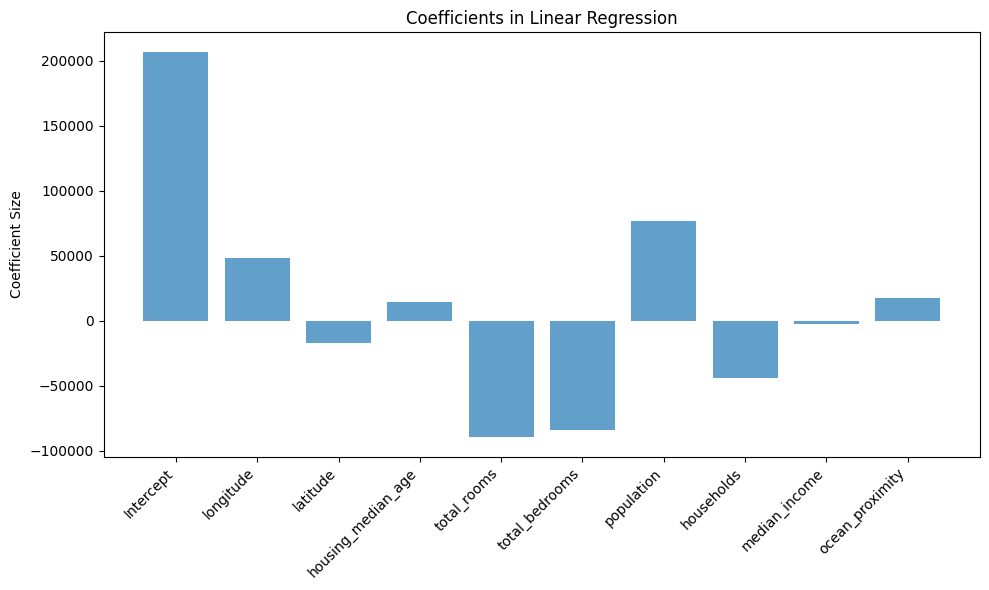

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting the feature importances
plt.figure(figsize=(10, 6))
y_pos = np.arange(len(coefficient_names))

# Criar o gráfico de barras baseado nos coeficientes extraídos
plt.bar(y_pos, coefficients, align='center', alpha=0.7)

# Configurar os eixos e rótulos do gráfico
plt.xticks(y_pos, coefficient_names, rotation=45, ha='right')
plt.ylabel('Coefficient Size')
plt.title('Coefficients in Linear Regression')

# Ajustar o layout para não cortar os nomes das variáveis
plt.tight_layout()
plt.show()